# Churn Prediction (2-Year Horizon)
**NAME:** Mudra Verma

**Objective:** Predict 2-year churn and optimize decision threshold for business cost.

## Business Cost Assumptions
- False Negative (missed churner): **$5,000**
- False Positive (unnecessary retention offer): **$200**

## Notebook Plan
1. Setup & paths  
2. Load + inspect data  
3. Clean & feature engineer  
4. Time-based validation split  
5. Build/train models  
6. Optimize threshold by business cost  
7. Evaluate + export outputs

In [67]:
# =========================
# 1) Setup
# =========================
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression, SGDClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FN_COST = 5000
FP_COST = 200

print('Libraries loaded.')

Libraries loaded.


### If using Google Colab, mount Google Drive

In [68]:
# =========================
# 2) Paths (edit once)
# =========================
# Option A (Local Jupyter):
DATA_PATH = 'customer_churn_1M.csv'
BASE_DIR = '.'

OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
METRICS_DIR = os.path.join(OUTPUT_DIR, 'metrics')
PLOTS_DIR = os.path.join(OUTPUT_DIR, 'plots')
MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')

for d in [OUTPUT_DIR, METRICS_DIR, PLOTS_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

TARGET_COL = 'churn'
DATE_COL = 'signup_date'

print('DATA_PATH:', DATA_PATH)
print('Output directories ready.')

DATA_PATH: customer_churn_1M.csv
Output directories ready.


## 3) Load and Inspect Data

In [69]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())
display(df.dtypes.head(20))

Shape: (67630, 32)


,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1.0,2.0,two_year,...,1.0,1.0,9.0,0.0,0.0,0.0,109.63,16.0,NaN,0.0
1,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1.0,22.0,one_year,...,0.0,1.0,7.0,0.0,3.0,1.0,63.25,134.0,585.0,0.0
2,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0.0,3.0,two_year,...,1.0,0.0,6.0,1.0,1.0,0.0,47.77,11.0,632.0,0.0
3,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1.0,6.0,two_year,...,0.0,1.0,5.0,2.0,2.0,1.0,50.82,6.0,569.0,0.0
4,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0.0,9.0,two_year,...,0.0,1.0,8.0,1.0,1.0,0.0,16.74,18.0,657.0,0.0


,0
customer_id,object
signup_date,object
age,int64
gender,object
annual_income,float64
education,object
marital_status,object
dependents,float64
tenure,float64
contract,object


In [70]:
def optimize_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
    for col in df.select_dtypes(include=['object']).columns:
        ratio = df[col].nunique(dropna=True) / max(len(df), 1)
        if ratio < 0.5:
            df[col] = df[col].astype('category')
    return df

df = optimize_dtypes(df)
print('Dtype optimization done.')

Dtype optimization done.


In [71]:
print('Target distribution (%):')
display((df[TARGET_COL].value_counts(normalize=True) * 100).rename('percent'))

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print('\nTop missing columns (%):')
display(missing_pct.head(15))

Target distribution (%):


,percent
churn,
0.0,89.989502
1.0,10.010498



Top missing columns (%):


,0
avg_monthly_gb,5.132338
credit_score,4.194884
num_complaints,3.019370
annual_income,3.009020
customer_satisfaction,1.999113
marital_status,0.001479
dependents,0.001479
senior_citizen,0.001479
totalcharges,0.001479
monthlycharges,0.001479


## 4) Feature Engineering and Outlier Handling

In [72]:
def add_date_features(df: pd.DataFrame, date_col: str) -> pd.DataFrame:
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        df['signup_year'] = df[date_col].dt.year
        df['signup_month'] = df[date_col].dt.month
        df['signup_quarter'] = df[date_col].dt.quarter
        df['signup_dayofweek'] = df[date_col].dt.dayofweek
    return df

def cap_outliers_iqr(df: pd.DataFrame, numeric_cols: list, iqr_mult: float = 1.5) -> pd.DataFrame:
    q1 = df[numeric_cols].quantile(0.25)
    q3 = df[numeric_cols].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_mult * iqr
    upper = q3 + iqr_mult * iqr
    df[numeric_cols] = df[numeric_cols].clip(lower=lower, upper=upper, axis=1)
    return df

df = add_date_features(df, DATE_COL)

num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL in num_cols_all:
    num_cols_all.remove(TARGET_COL)

df = cap_outliers_iqr(df, num_cols_all, iqr_mult=1.5)
print('Feature engineering + outlier capping complete.')

Feature engineering + outlier capping complete.


## 5) Time-Based Split (Validation Strategy)
Train on earlier records, validate on later records to mimic production and reduce temporal leakage.

In [73]:
# Sort by signup date for time split
df = df.sort_values(DATE_COL).reset_index(drop=True)

# Drop rows where the target is missing
df = df.dropna(subset=[TARGET_COL])

# Drop raw date after sorting
df_model = df.drop(columns=[DATE_COL])

split_idx = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_idx].copy()
val_df = df_model.iloc[split_idx:].copy()

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL].astype(int)

X_val = val_df.drop(columns=[TARGET_COL])
y_val = val_df[TARGET_COL].astype(int)

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)

Train: (54103, 34) (54103,)
Val  : (13526, 34) (13526,)


In [74]:
# Optional memory safety step
num_cols_tmp = X_train.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols_tmp:
    X_train[c] = X_train[c].astype('float32')
    X_val[c] = X_val[c].astype('float32')

print('Numeric columns cast to float32.')

Numeric columns cast to float32.


## 6) Preprocess + Train Models
Using sparse one-hot encoding to avoid memory crashes.

In [75]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # sparse
])

preprocess = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

logit_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

sgd_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', SGDClassifier(
        loss='log_loss',
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

print('Pipelines defined.')

Pipelines defined.


In [76]:
# =========================
# TUNING BLOCK (Version 1 improvements)
# - High-cardinality bucketing
# - Logistic hyperparam tuning (C, class_weight)
# - Threshold optimization by business cost
# - Optional probability calibration
# =========================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report

# Business costs (should already exist)
FN_COST = 5000
FP_COST = 200
RANDOM_STATE = 42

# ---------- helper functions ----------
def evaluate_at_threshold(y_true, y_prob, threshold, fn_cost=FN_COST, fp_cost=FP_COST):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fn * fn_cost + fp * fp_cost
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return {
        "threshold": threshold,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "precision": precision, "recall": recall,
        "total_cost": total_cost
    }

def find_optimal_threshold(y_true, y_prob, step=0.01):
    rows = []
    for t in np.arange(step, 1.0, step):
        rows.append(evaluate_at_threshold(y_true, y_prob, t))
    table = pd.DataFrame(rows).sort_values("total_cost", ascending=True).reset_index(drop=True)
    best_t = float(table.loc[0, "threshold"])
    return table, best_t

def apply_top_n_bucketing(train_df, val_df, cat_cols, top_n=100):
    Xtr = train_df.copy()
    Xva = val_df.copy()
    for c in cat_cols:
        tr_col = Xtr[c].astype(str).fillna("MISSING")
        va_col = Xva[c].astype(str).fillna("MISSING")
        top_levels = tr_col.value_counts().nlargest(top_n).index
        Xtr[c] = np.where(tr_col.isin(top_levels), tr_col, "OTHER")
        Xva[c] = np.where(va_col.isin(top_levels), va_col, "OTHER")
    return Xtr, Xva

# ---------- copy features ----------
Xtr_raw = X_train.copy()
Xva_raw = X_val.copy()

num_cols = Xtr_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = Xtr_raw.select_dtypes(exclude=[np.number]).columns.tolist()

# 1) high-cardinality handling
Xtr_b, Xva_b = apply_top_n_bucketing(Xtr_raw, Xva_raw, cat_cols, top_n=100)

# 2) preprocess (sparse-safe)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# 3) grid over C and class_weight
C_grid = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
CW_grid = ["balanced", {0:1, 1:3}, {0:1, 1:5}]

results = []
artifacts = {}  # store model/prob/cost table per run

run_id = 0
for C in C_grid:
    for cw in CW_grid:
        run_id += 1
        name = f"logit_C={C}_cw={cw}"

        model = Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(
                C=C,
                max_iter=1000,
                class_weight=cw,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

        model.fit(Xtr_b, y_train)
        val_prob = model.predict_proba(Xva_b)[:, 1]

        roc = roc_auc_score(y_val, val_prob)
        pr = average_precision_score(y_val, val_prob)

        cost_table, best_t = find_optimal_threshold(y_val.values, val_prob, step=0.01)
        best_row = cost_table.iloc[0].to_dict()

        results.append({
            "run_id": run_id,
            "model_name": name,
            "C": C,
            "class_weight": str(cw),
            "ROC_AUC": roc,
            "PR_AUC": pr,
            "best_threshold": best_t,
            "best_cost": best_row["total_cost"],
            "precision_at_best_t": best_row["precision"],
            "recall_at_best_t": best_row["recall"],
            "fp_at_best_t": int(best_row["fp"]),
            "fn_at_best_t": int(best_row["fn"]),
            "tp_at_best_t": int(best_row["tp"]),
            "tn_at_best_t": int(best_row["tn"])
        })

        artifacts[name] = {
            "model": model,
            "val_prob": val_prob,
            "cost_table": cost_table,
            "best_threshold": best_t
        }

# 4) optional calibrated probability run on best base model
results_df = pd.DataFrame(results).sort_values("best_cost", ascending=True).reset_index(drop=True)
best_base_name = results_df.iloc[0]["model_name"]
best_base_model = artifacts[best_base_name]["model"]

cal_model = CalibratedClassifierCV(best_base_model, method="sigmoid", cv=3)
cal_model.fit(Xtr_b, y_train)
val_prob_cal = cal_model.predict_proba(Xva_b)[:, 1]

roc_cal = roc_auc_score(y_val, val_prob_cal)
pr_cal = average_precision_score(y_val, val_prob_cal)
cost_table_cal, best_t_cal = find_optimal_threshold(y_val.values, val_prob_cal, step=0.01)
best_row_cal = cost_table_cal.iloc[0].to_dict()

cal_row = {
    "run_id": 999,
    "model_name": f"CALIBRATED({best_base_name})",
    "C": np.nan,
    "class_weight": "inherited",
    "ROC_AUC": roc_cal,
    "PR_AUC": pr_cal,
    "best_threshold": best_t_cal,
    "best_cost": best_row_cal["total_cost"],
    "precision_at_best_t": best_row_cal["precision"],
    "recall_at_best_t": best_row_cal["recall"],
    "fp_at_best_t": int(best_row_cal["fp"]),
    "fn_at_best_t": int(best_row_cal["fn"]),
    "tp_at_best_t": int(best_row_cal["tp"]),
    "tn_at_best_t": int(best_row_cal["tn"])
}

results_df = pd.concat([results_df, pd.DataFrame([cal_row])], ignore_index=True)
results_df = results_df.sort_values("best_cost", ascending=True).reset_index(drop=True)

display(results_df.head(15))

# 5) finalize winner (could be calibrated or base)
winner_name = results_df.iloc[0]["model_name"]
print("Winner:", winner_name)

if winner_name.startswith("CALIBRATED("):
    final_model = cal_model
    final_val_prob = val_prob_cal
    final_cost_table = cost_table_cal
    final_best_t = best_t_cal
else:
    final_model = artifacts[winner_name]["model"]
    final_val_prob = artifacts[winner_name]["val_prob"]
    final_cost_table = artifacts[winner_name]["cost_table"]
    final_best_t = artifacts[winner_name]["best_threshold"]

default_eval = evaluate_at_threshold(y_val.values, final_val_prob, 0.50)
optimal_eval = evaluate_at_threshold(y_val.values, final_val_prob, final_best_t)

print(f"Default cost @0.50: ${default_eval['total_cost']:,.0f}")
print(f"Optimal cost @{final_best_t:.2f}: ${optimal_eval['total_cost']:,.0f}")
print(f"Estimated savings: ${default_eval['total_cost'] - optimal_eval['total_cost']:,.0f}")

# final confusion/report at optimal threshold
y_pred_opt = (final_val_prob >= final_best_t).astype(int)
print("\nConfusion Matrix (winner @ optimal threshold):")
print(confusion_matrix(y_val, y_pred_opt))
print("\nClassification Report (winner @ optimal threshold):")
print(classification_report(y_val, y_pred_opt, digits=4))

# expose these for your next cells
tuning_results_df = results_df
best_model_name = winner_name
best_threshold = final_best_t
best_prob = final_val_prob
cost_table = final_cost_table

,run_id,model_name,C,class_weight,ROC_AUC,PR_AUC,best_threshold,best_cost,precision_at_best_t,recall_at_best_t,fp_at_best_t,fn_at_best_t,tp_at_best_t,tn_at_best_t
0,999,CALIBRATED(logit_C=0.5_cw=balanced),NaN,inherited,0.682561,0.204294,0.05,2302200.0,0.113491,0.948640,9811,68,1256,2391
1,10,logit_C=0.5_cw=balanced,0.50,balanced,0.682584,0.204494,0.32,2304000.0,0.115016,0.941843,9595,77,1247,2607
2,13,logit_C=1.0_cw=balanced,1.00,balanced,0.682650,0.204481,0.31,2305800.0,0.113131,0.949396,9854,67,1257,2348
3,1,logit_C=0.05_cw=balanced,0.05,balanced,0.682578,0.204242,0.32,2305800.0,0.114738,0.942598,9629,76,1248,2573
4,19,logit_C=5.0_cw=balanced,5.00,balanced,0.682615,0.204360,0.31,2306000.0,0.113121,0.949396,9855,67,1257,2347
5,16,logit_C=2.0_cw=balanced,2.00,balanced,0.682593,0.204361,0.31,2306000.0,0.113121,0.949396,9855,67,1257,2347
6,8,"logit_C=0.2_cw={0: 1, 1: 3}",0.20,"{0: 1, 1: 3}",0.682533,0.204276,0.13,2306400.0,0.112753,0.950906,9907,65,1259,2295
7,17,"logit_C=2.0_cw={0: 1, 1: 3}",2.00,"{0: 1, 1: 3}",0.682525,0.204280,0.13,2306800.0,0.112906,0.950151,9884,66,1258,2318
8,20,"logit_C=5.0_cw={0: 1, 1: 3}",5.00,"{0: 1, 1: 3}",0.682521,0.204268,0.13,2307200.0,0.112886,0.950151,9886,66,1258,2316
9,7,logit_C=0.2_cw=balanced,0.20,balanced,0.682615,0.204445,0.31,2307200.0,0.113060,0.949396,9861,67,1257,2341


Winner: CALIBRATED(logit_C=0.5_cw=balanced)
Default cost @0.50: $6,585,000
Optimal cost @0.05: $2,302,200
Estimated savings: $4,282,800

Confusion Matrix (winner @ optimal threshold):
[[2391 9811]
 [  68 1256]]

Classification Report (winner @ optimal threshold):
              precision    recall  f1-score   support

           0     0.9723    0.1960    0.3262     12202
           1     0.1135    0.9486    0.2027      1324

    accuracy                         0.2696     13526
   macro avg     0.5429    0.5723    0.2644     13526
weighted avg     0.8883    0.2696    0.3141     13526



## 7) Threshold Optimization for Business Cost

In [77]:
@dataclass
class CostResult:
    threshold: float
    tn: int
    fp: int
    fn: int
    tp: int
    total_cost: float
    precision: float
    recall: float

def evaluate_at_threshold(y_true, y_prob, threshold, fn_cost=FN_COST, fp_cost=FP_COST):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fn * fn_cost + fp * fp_cost
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return CostResult(threshold, tn, fp, fn, tp, total_cost, precision, recall)

def find_optimal_threshold(y_true, y_prob, step=0.01):
    rows = []
    for t in np.arange(step, 1.0, step):
        r = evaluate_at_threshold(y_true, y_prob, t)
        rows.append({
            'threshold': r.threshold,
            'tn': r.tn, 'fp': r.fp, 'fn': r.fn, 'tp': r.tp,
            'precision': r.precision, 'recall': r.recall,
            'total_cost': r.total_cost
        })
    table = pd.DataFrame(rows).sort_values('total_cost', ascending=True).reset_index(drop=True)
    return table, table.loc[0, 'threshold']

cost_table, best_threshold = find_optimal_threshold(y_val.values, best_prob, step=0.01)
default_eval = evaluate_at_threshold(y_val.values, best_prob, 0.50)
optimal_eval = evaluate_at_threshold(y_val.values, best_prob, best_threshold)

print(f'Best threshold: {best_threshold:.2f}')
print(f'Cost at threshold 0.50: ${default_eval.total_cost:,.0f}')
print(f'Cost at threshold {best_threshold:.2f}: ${optimal_eval.total_cost:,.0f}')
print(f'Estimated savings: ${default_eval.total_cost - optimal_eval.total_cost:,.0f}')

display(cost_table.head(10))

Best threshold: 0.05
Cost at threshold 0.50: $6,585,000
Cost at threshold 0.05: $2,302,200
Estimated savings: $4,282,800


,threshold,tn,fp,fn,tp,precision,recall,total_cost
0,0.05,2391,9811,68,1256,0.113491,0.948640,2302200
1,0.04,1288,10914,32,1292,0.105850,0.975831,2342800
2,0.03,382,11820,6,1318,0.100320,0.995468,2394000
3,0.06,3445,8757,130,1194,0.119988,0.901813,2401400
4,0.02,15,12187,0,1324,0.097994,1.000000,2437400
5,0.01,0,12202,0,1324,0.097886,1.000000,2440400
6,0.07,4469,7733,197,1127,0.127201,0.851208,2531600
7,0.08,5458,6744,275,1049,0.134608,0.792296,2723800
8,0.09,6348,5854,363,961,0.141012,0.725831,2985800
9,0.10,7246,4956,436,888,0.151951,0.670695,3171200


## 8) Final Evaluation at Optimal Threshold

In [78]:
y_pred_opt = (best_prob >= best_threshold).astype(int)

print('Confusion Matrix (Optimal Threshold):')
print(confusion_matrix(y_val, y_pred_opt))

print('\nClassification Report (Optimal Threshold):')
print(classification_report(y_val, y_pred_opt, digits=4))

Confusion Matrix (Optimal Threshold):
[[2391 9811]
 [  68 1256]]

Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

           0     0.9723    0.1960    0.3262     12202
           1     0.1135    0.9486    0.2027      1324

    accuracy                         0.2696     13526
   macro avg     0.5429    0.5723    0.2644     13526
weighted avg     0.8883    0.2696    0.3141     13526



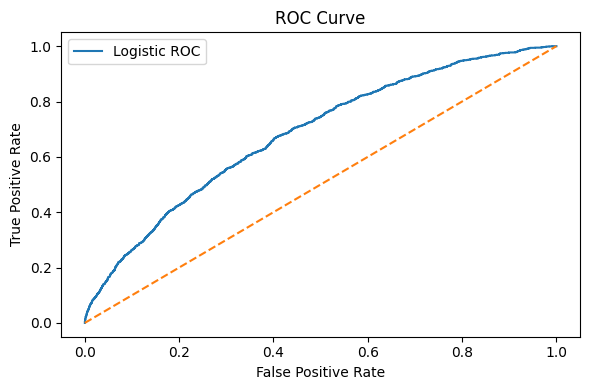

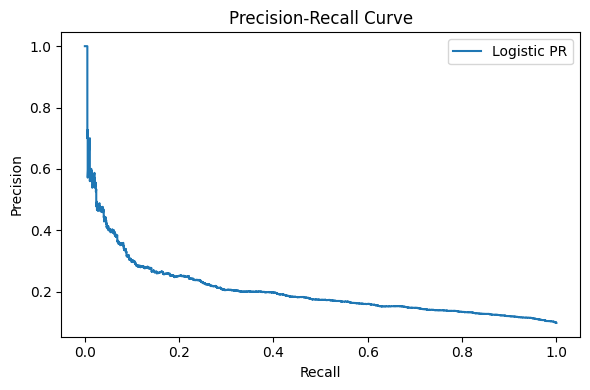

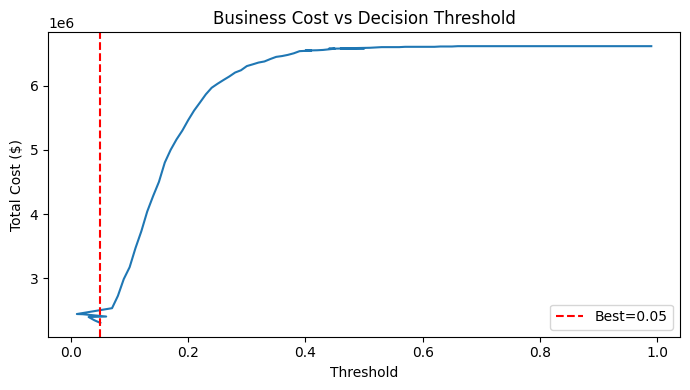

In [79]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_val, best_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'{best_name} ROC')
plt.plot([0,1], [0,1], '--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'roc_curve.png'), dpi=150)
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, best_prob)
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f'{best_name} PR')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'pr_curve.png'), dpi=150)
plt.show()

# Cost vs Threshold
plt.figure(figsize=(7,4))
plt.plot(cost_table['threshold'], cost_table['total_cost'])
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best={best_threshold:.2f}')
plt.title('Business Cost vs Decision Threshold')
plt.xlabel('Threshold')
plt.ylabel('Total Cost ($)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'cost_vs_threshold.png'), dpi=150)
plt.show()

## 9) Save Output Tables

In [80]:
metrics_df.to_csv(os.path.join(METRICS_DIR, 'model_probability_metrics.csv'), index=True)
cost_table.to_csv(os.path.join(METRICS_DIR, 'threshold_cost_table.csv'), index=False)

summary = pd.DataFrame([{
    'selected_model': best_name,
    'optimal_threshold': float(best_threshold),
    'default_cost': float(default_eval.total_cost),
    'optimal_cost': float(optimal_eval.total_cost),
    'estimated_savings': float(default_eval.total_cost - optimal_eval.total_cost),
    'fn_cost': FN_COST,
    'fp_cost': FP_COST
}])
summary.to_csv(os.path.join(METRICS_DIR, 'business_summary.csv'), index=False)

print('Saved:')
print('-', os.path.join(METRICS_DIR, 'model_probability_metrics.csv'))
print('-', os.path.join(METRICS_DIR, 'threshold_cost_table.csv'))
print('-', os.path.join(METRICS_DIR, 'business_summary.csv'))

Saved:
- ./outputs/metrics/model_probability_metrics.csv
- ./outputs/metrics/threshold_cost_table.csv
- ./outputs/metrics/business_summary.csv


## Task 2 Answer (Validation Strategy)
I used a time-based holdout validation strategy rather than a random split. Since the use case is to predict future churn risk from historical behavior, training on earlier signup periods and validating on later periods better reflects real production conditions and reduces temporal leakage risk. This provides a more realistic estimate of future business performance.

## Task 4 Answer (GCP Architecture for 100M rows)
If volume grows to 100M rows, I would use a GCP-native pipeline: raw ingestion to Cloud Storage, large-scale transformation in BigQuery (and/or Dataflow for streaming/complex ETL), and curated feature tables stored in BigQuery. Model training, experiment tracking, and model registry would run on Vertex AI. Batch scoring pipelines (Vertex Pipelines or Cloud Composer) would write churn scores back to BigQuery for activation by CRM/marketing systems. For online use cases, the model can be deployed to a Vertex AI endpoint. Monitoring would include data quality checks, calibration/performance drift, and business KPIs such as retention uplift and cost per saved customer.